# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos.**

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura perde metade dos pontos do critério.

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Semente fixa.
RANDOM_STATE = 42

# Caminhos dos arquivos com base na estrutura do projeto
RAW_APP = Path("../data/raw/application_record.csv")
RAW_CREDIT = Path("../data/raw/credit_record.csv")

# A variável alvo será construída no notebook 02, mas deixamos o nome configurado
TARGET = "target"

# Configuração para mostrar todas as colunas
pd.set_option("display.max_columns", None)

**Explicação do código:** Importamos as bibliotecas necessárias (`pandas` para manipulação de dados, `matplotlib` e `seaborn` para gráficos) e a biblioteca `Path` para lidar com caminhos de arquivos de forma compatível com qualquer sistema operacional. 
Definimos o `RANDOM_STATE = 42` para reprodutibilidade, mapeamos os caminhos dos arquivos brutos na pasta `data/raw/` e na última linha de código, configuramos o Pandas para não ocultar colunas ao exibir os DataFrames.

In [11]:
# Carregando os datasets
df_aplication = pd.read_csv(RAW_APP)
df_credit = pd.read_csv(RAW_CREDIT)

# Exibindo as primeiras linhas de cada Dataset
print("=== Application Record ===")
display(df_aplication.head())

print("\n=== Credit Record ===")
display(df_credit.head())

=== Application Record ===


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0



=== Credit Record ===


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


**Explicação do código:** Carregamos os dois arquivos CSV para a memória em DataFrames distintos (`df_aplication` e `df_credit`). A função `display()` combinada com `.head()` exibe as primeiras 5 linhas de cada tabela, permitindo uma inspeção visual cruzada das estruturas de perfil demográfico e de histórico financeiro.

In [12]:
print("======= Visão Geral: Application Record =======")
print(f"Dimensões: {df_aplication.shape}\n")
df_aplication.info()
display(df_aplication.describe().T)

print("\n" + "="*50 + "\n")

print("======= Visão Geral: Credit Record =======")
print(f"Dimensões: {df_credit.shape}\n")
df_credit.info()
display(df_credit.describe().T)

======= Visão Geral: Application Record =======
Dimensões: (438557, 18)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  


,count,mean,std,min,25%,50%,75%,max
ID,438557.0,6.022176e+06,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CNT_CHILDREN,438557.0,4.273903e-01,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,1.875243e+05,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
DAYS_BIRTH,438557.0,-1.599790e+04,4185.030007,-25201.0,-19483.0,-15630.0,-12514.0,-7489.0
DAYS_EMPLOYED,438557.0,6.056368e+04,138767.799647,-17531.0,-3103.0,-1467.0,-371.0,365243.0
FLAG_MOBIL,438557.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,438557.0,2.061328e-01,0.404527,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,438557.0,2.877710e-01,0.452724,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,438557.0,1.082071e-01,0.310642,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,438557.0,2.194465e+00,0.897207,1.0,2.0,2.0,3.0,20.0




======= Visão Geral: Credit Record =======
Dimensões: (1048575, 3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


,count,mean,std,min,25%,50%,75%,max
ID,1048575.0,5.068286e+06,46150.578505,5001711.0,5023644.0,5062104.0,5113856.0,5150487.0
MONTHS_BALANCE,1048575.0,-1.913700e+01,14.023498,-60.0,-29.0,-17.0,-7.0,0.0


**Explicação do código:** Utilizamos `.shape` para extrair o volume de linhas e colunas de cada base. O método `.info()` detalha os tipos de dados e a presença de nulos, enquanto `.describe().T` exibe as estatísticas descritivas básicas.

**Interpretação:** Verificando os dois datasets, observamos que há um campo em comum, o `ID`, que será utilizado para cruzar informações. 
* A base `application_record` possui 438.557 registros e 18 variáveis cadastrais. As métricas temporais (`DAYS_BIRTH` e `DAYS_EMPLOYED`) estão em formato negativo (contagem regressiva de dias) e há um outlier extremo na coluna de emprego (365243), sugerindo um marcador para desempregados ou pensionistas. 
* A base `credit_record` é longitudinal (acompanha o comportamento ao longo do tempo), possuindo mais de 1 milhão de registros (1.048.575) distribuídos em 3 colunas, detalhando o status de pagamento mensal (`STATUS`) por mês de referência (`MONTHS_BALANCE`). 
* Ambas as bases aparentam estar bem preenchidas, sem valores nulos explícitos indicados nas colunas principais nesta primeira contagem do `.info()`.

## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [9]:
print("======= Visão Geral: Application Record =======")
print(f"Dimensões: {df_aplication.shape}\n")
df_aplication.info()
display(df_aplication.describe().T)

print("\n" + "="*50 + "\n")

print("======= Visão Geral: Credit Record =======")
print(f"Dimensões: {df_credit.shape}\n")
df_credit.info()
display(df_credit.describe().T)

======= Visão Geral: Application Record =======
Dimensões: (438557, 18)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  


,count,mean,std,min,25%,50%,75%,max
ID,438557.0,6.022176e+06,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CNT_CHILDREN,438557.0,4.273903e-01,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,1.875243e+05,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
DAYS_BIRTH,438557.0,-1.599790e+04,4185.030007,-25201.0,-19483.0,-15630.0,-12514.0,-7489.0
DAYS_EMPLOYED,438557.0,6.056368e+04,138767.799647,-17531.0,-3103.0,-1467.0,-371.0,365243.0
FLAG_MOBIL,438557.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,438557.0,2.061328e-01,0.404527,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,438557.0,2.877710e-01,0.452724,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,438557.0,1.082071e-01,0.310642,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,438557.0,2.194465e+00,0.897207,1.0,2.0,2.0,3.0,20.0




======= Visão Geral: Credit Record =======
Dimensões: (1048575, 3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


,count,mean,std,min,25%,50%,75%,max
ID,1048575.0,5.068286e+06,46150.578505,5001711.0,5023644.0,5062104.0,5113856.0,5150487.0
MONTHS_BALANCE,1048575.0,-1.913700e+01,14.023498,-60.0,-29.0,-17.0,-7.0,0.0


**Explicação do código:** Utilizamos `.shape` para extrair o volume de linhas e colunas de cada base. O método `.info()` detalha os tipos de dados e a presença de nulos, enquanto `.describe().T` exibe as estatísticas descritivas básicas.

**Interpretação:** Verificando os dois datasets, observamos que há um campo em comum, o `ID`, que será utilizado para cruzar informações. 
* A base `application_record` possui 438.557 registros e 18 variáveis cadastrais. As métricas temporais (`DAYS_BIRTH` e `DAYS_EMPLOYED`) estão em formato negativo (contagem regressiva de dias) e há um outlier extremo na coluna de emprego (365243), sugerindo um marcador para desempregados ou pensionistas. 
* A base `credit_record` é longitudinal (acompanha o comportamento ao longo do tempo), possuindo mais de 1 milhão de registros (1.048.575) distribuídos em 3 colunas, detalhando o status de pagamento mensal (`STATUS`) por mês de referência (`MONTHS_BALANCE`). 
* Ambas as bases aparentam estar bem preenchidas, sem valores nulos explícitos indicados nas colunas principais nesta primeira contagem do `.info()`.

In [ ]:
df.info()
df.describe().T

## 2. Distribuição das variáveis

**Explicação do código:** A seguir, geramos dois histogramas utilizando a biblioteca `seaborn` para analisar a distribuição financeira e demográfica. Na renda, aplicamos um filtro visual (`< 500000`) para evitar que outliers extremos distorçam o gráfico. Na idade, convertemos a coluna `DAYS_BIRTH` para anos positivos, dividindo por `-365.25`.

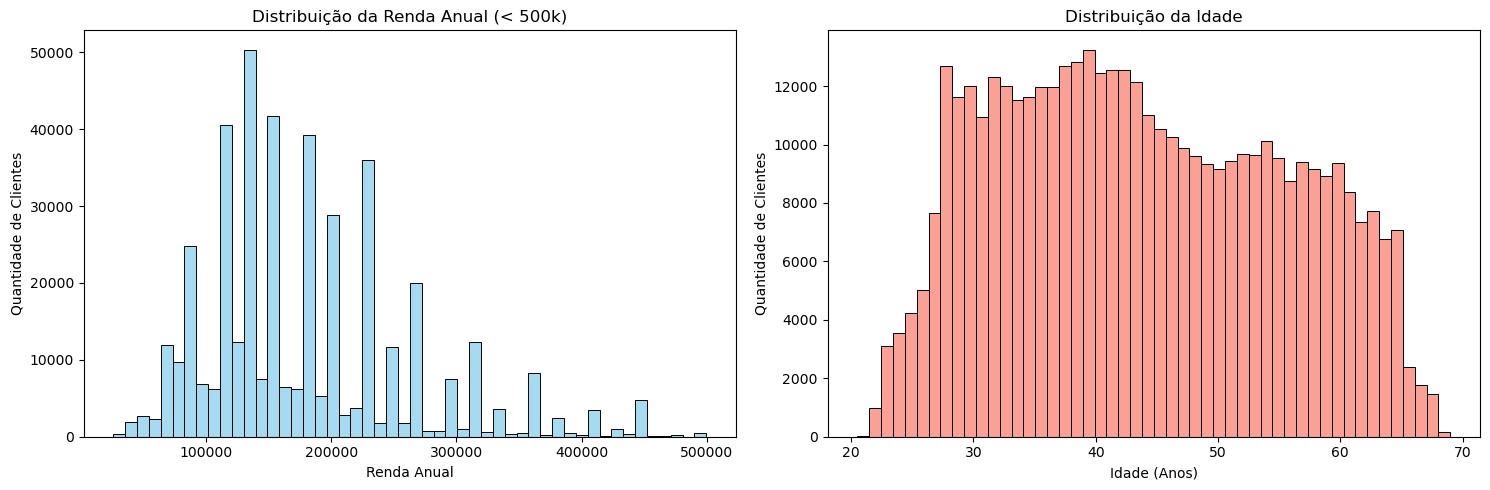

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Distribuição da Renda
sns.histplot(df_aplication[df_aplication['AMT_INCOME_TOTAL'] < 500000]['AMT_INCOME_TOTAL'], bins=50, ax=ax[0], color='skyblue')
ax[0].set_title('Distribuição da Renda Anual (< 500k)')
ax[0].set_xlabel('Renda Anual')
ax[0].set_ylabel('Quantidade de Clientes')

# Distribuição da Idade
idades_anos = df_aplication['DAYS_BIRTH'] / -365.25
sns.histplot(idades_anos, bins=50, ax=ax[1], color='salmon')
ax[1].set_title('Distribuição da Idade')
ax[1].set_xlabel('Idade (Anos)')
ax[1].set_ylabel('Quantidade de Clientes')

plt.tight_layout()
plt.show()

**Interpretação:** A distribuição da renda anual (`AMT_INCOME_TOTAL`) apresenta uma forte assimetria à direita (long tail), padrão clássico em dados financeiros indicando concentração de massa em faixas de renda menores (100k a 200k). A distribuição de idade aproxima-se de uma simetria normal, evidenciando que o volume principal de solicitações de crédito advém de pessoas entre 30 e 45 anos, compondo a faixa demográfica mais ativa.

## 3. Correlações

**Interpretação:** _comente cada correlação relevante, uma a uma._

In [ ]:
# heatmap de correlação

## 4. Outliers

**Interpretação:** _remover, winsorizar ou manter? Justifique._

In [ ]:
# detecção de outliers

## 5. Balanceamento de classes

**Interpretação:** _qual a proporção entre as classes e o que isso implica na escolha das métricas?_

In [ ]:
df[TARGET].value_counts(normalize=True)

## 6. Síntese da EDA

_Amarre os achados em uma narrativa única — é ela que vira o storytelling da apresentação._